<a href="https://colab.research.google.com/github/Hari2020codes/Machine-Learning/blob/main/MultiLinearRegressionCustonData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

# Upload the file
uploaded = files.upload()

# Get the filename (assuming only one file is uploaded)
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Check if the uploaded file is named 'aptitude.xlsx', if not, you might need to rename it or adjust the pandas read_excel call
  if fn != 'car_data.xlsx':
    print(f"Warning: Uploaded file is named '{fn}'. The code expects 'aptitude.xlsx'.")
    print(f"Please ensure you rename '{fn}' to 'aptitude.xlsx' or update the `pd.read_excel` call.")


Saving car_data.xlsx to car_data (2).xlsx
User uploaded file "car_data (2).xlsx" with length 5484 bytes
Please ensure you rename 'car_data (2).xlsx' to 'aptitude.xlsx' or update the `pd.read_excel` call.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import pandas as pd
from sklearn.metrics import r2_score
df = pd.read_excel('car_data.xlsx')
X=df[['Weight', 'Volume']]
y =df[['CO2']]
X=X.values
y =y.values
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Training Data (X):\n", x_train)
print("Training Labels (y):\n", y_train)
regr = linear_model.LinearRegression()
regr.fit(x_train, y_train)
predictedCO2 = regr.predict([[2300, 1300]])
print("\nPredicted CO2 for [2300,1300]:", predictedCO2)
score = regr.score(x_test, y_test)
print("\nModel R² Score:", round(score, 2))

Training Data (X):
 [[1150 1600]
 [1160 1200]
 [1109 1500]
 [1365 1500]
 [ 865 1500]
 [ 790 1000]
 [ 929 1400]]
Training Labels (y):
 [[ 99]
 [ 95]
 [ 90]
 [ 92]
 [ 90]
 [ 99]
 [105]]

Predicted CO2 for [2300,1300]: [[87.65719553]]

Model R² Score: -0.72


prog 9 Multiple Regression using Public Domain Datase

Dataset Loaded Successfully!

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

 Regression Equation:
y = 150.84 + (669.56 × bmi) + (326.92 × bp) + (-235.49 × s1) + (561.27 × s5)

 Model Performance Metrics:
Mean Squared Error (MSE): 2799.73
R² Score: 0.48

 Predicted Target Value for New Data: 211.87


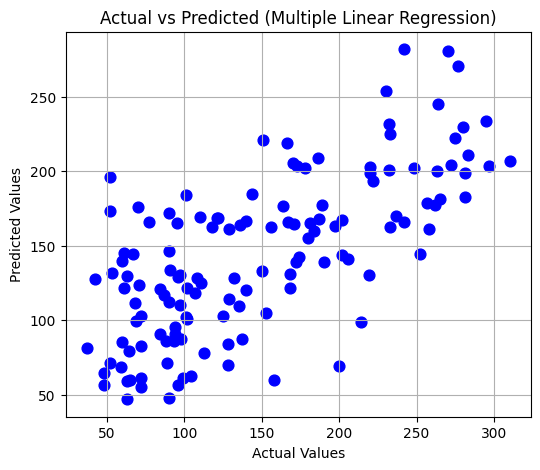

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame
print("Dataset Loaded Successfully!\n")
print(df.head())
X=df[['bmi', 'bp', 's1', 's5']]
y =df['target']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
print("\n Regression Equation:")
print(f"y = {model.intercept_:.2f}", end="")

for feature, coef in zip(X.columns, model.coef_):
  print(f" + ({coef:.2f} × {feature})", end="")
print("\n")
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(" Model Performance Metrics:")
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 2))
new_data = pd.DataFrame([[0.05, 0.03, 0.02, 0.04]], columns=['bmi', 'bp', 's1', 's5'])
predicted_value = model.predict(new_data)
print("\n Predicted Target Value for New Data:", round(predicted_value[0], 2))
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, color='blue', s=60)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Multiple Linear Regression)")

plt.grid(True)
plt.show()

